In [1]:
import glob
import os

import matplotlib.pyplot as plt
import pandas as pd
import scanpy as sc
import seaborn as sns

In [2]:
INPUT_DIR = "inputs"

# SubQ

In [5]:
adata_an = sc.read_h5ad(os.path.join(INPUT_DIR, "anndatas", 'sq_reannotated_finely.h5ad'))
adata_nan = sc.read_h5ad(os.path.join(INPUT_DIR, "anndatas", "sq_raw.h5ad"))

In [6]:
adata_nan.obs["cell_type"] = None
idx = adata_nan.obs_names.isin(adata_an.obs_names)
adata_nan.obs.loc[idx, "cell_type"] = adata_an.obs.loc[adata_nan.obs_names[idx], "cell_type"].values
adata_nan.obs.loc[idx, "cell_type1"] = adata_an.obs.loc[adata_nan.obs_names[idx], "cell_type1"].values

In [7]:
adata_nan.obs.value_counts(["cell_type", "cell_type1"]).sort_index()

cell_type  cell_type1  
B cells    B cells         42
           CD4+ T cells     0
           CD8+ T cells     0
           FAPs             0
           GD T cells       0
                           ..
T cells    VECs             0
           cDC1s            0
           cDC2Bs           0
           mNK1 cells       0
           mNK2 cells       0
Name: count, Length: 144, dtype: int64

In [8]:
adata_nan.obs["cell_type"].isna().sum()

np.int64(1941)

In [9]:
adata_nan.obs.value_counts("status")

status
singlet       10596
doublet         445
unassigned       27
Name: count, dtype: int64

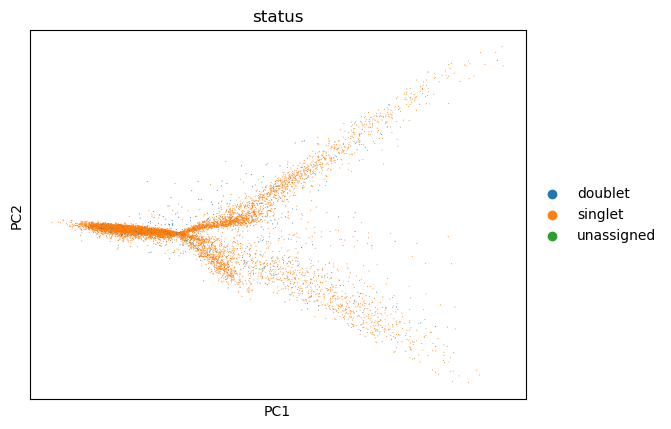

In [10]:
sc.experimental.pp.recipe_pearson_residuals(adata_nan)

sc.pl.pca(
    adata_nan,
    color=["status",],
    # dimensions=[(0, 1), (2, 3), (0, 1), (2, 3)],
    # ncols=2,
    size=2,
)

/opt/miniconda3/envs/sc/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


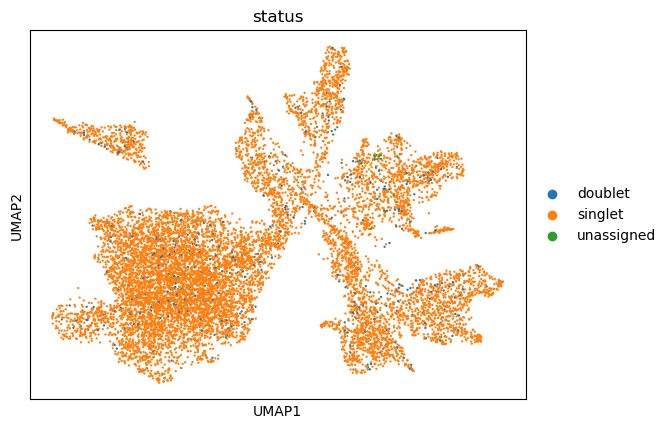

In [11]:
sc.pp.neighbors(adata_nan, n_pcs=30, n_neighbors=15)
sc.tl.umap(adata_nan, )
sc.pl.umap(adata_nan, color=["status",])

In [12]:
sc.tl.leiden(adata_nan, flavor="igraph", n_iterations=2, resolution=2)

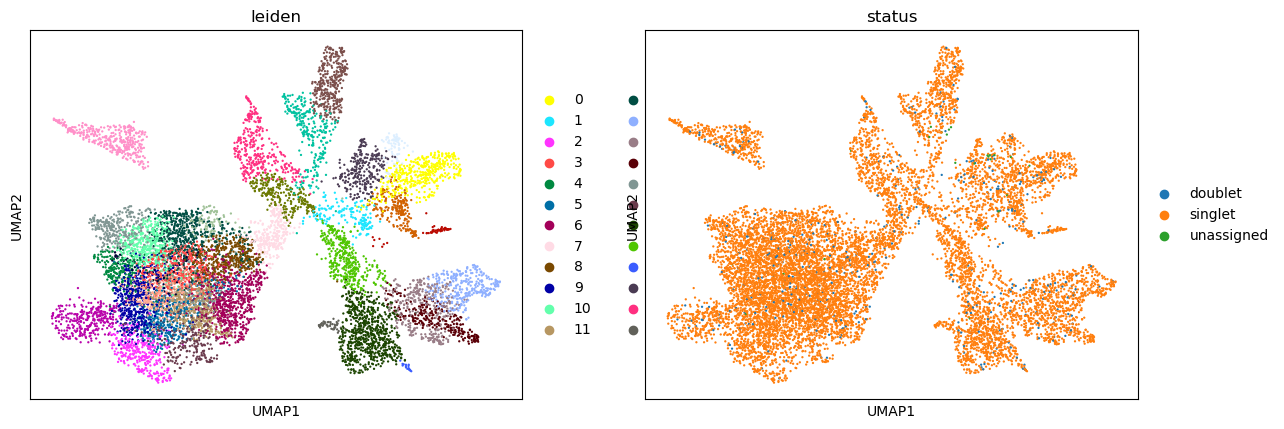

In [13]:
sc.pl.umap(adata_nan, color=["leiden", "status"])

In [14]:
vc = adata_nan.obs.value_counts(["leiden", "cell_type"], dropna=False).sort_index()
with pd.option_context('display.max_rows', 200):
    print(vc)

leiden  cell_type     
0       B cells             0
        ECs                 0
        FAPs                3
        Myeloid cells     386
        Myofibroblasts      0
                         ... 
34      Myofibroblasts      0
        NK cells            0
        Pre-adipocytes      4
        T cells             0
        nan                 8
Name: count, Length: 315, dtype: int64


In [16]:
%matplotlib inline

Cohorts: ['Healthy', 'Unhealthy']
  Healthy: 23 / 3684 predicted doublets (0.6%)  threshold=0.3609


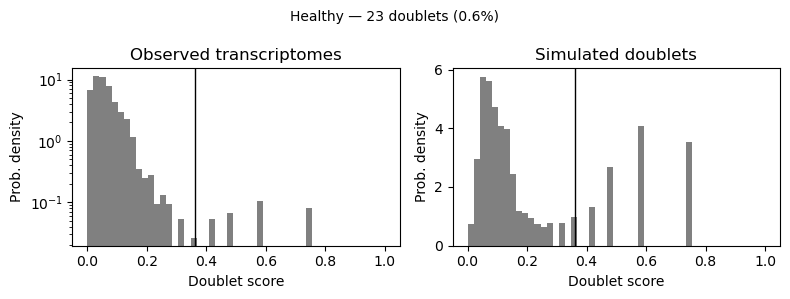

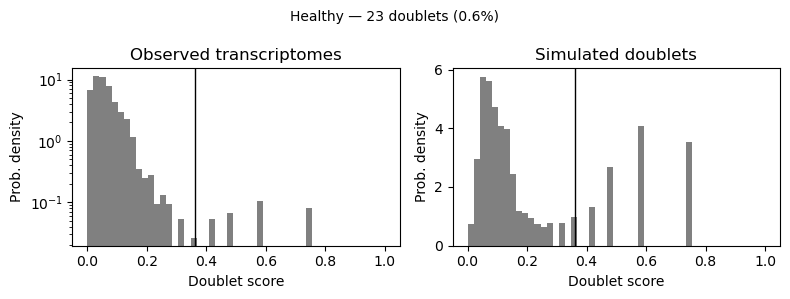

  Unhealthy: 139 / 7384 predicted doublets (1.9%)  threshold=0.2834


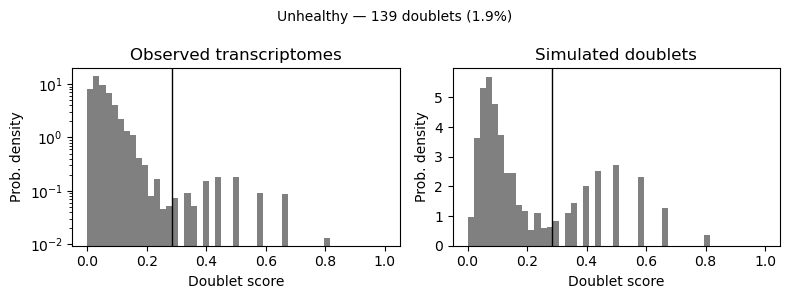

Agreement: Scrublet (transcriptomic) vs souporcell (genetic) — all cells:
scrublet_call  scrublet_doublet  scrublet_singlet    All
status                                                  
doublet                     104               341    445
singlet                      58             10538  10596
unassigned                    0                27     27
All                         162             10906  11068
Per cohort:
Healthy:
scrublet_call  scrublet_doublet  scrublet_singlet   All
status                                                 
doublet                      12                60    72
singlet                      11              3595  3606
unassigned                    0                 6     6
All                          23              3661  3684
Unhealthy:
scrublet_call  scrublet_doublet  scrublet_singlet   All
status                                                 
doublet                      92               281   373
singlet                      47              694

In [17]:
import scrublet as scr
import scipy.sparse as sp
import numpy as np
import matplotlib.pyplot as plt

# Healthy and Unhealthy cohorts were captured in two separate 10x pools.
# Within each pool, souporcell demultiplexed ~5 individuals by genotype clustering.
# Doublets can only form within the same capture pool, so Scrublet is run
# separately per cohort.
# adata_nan.obs["status"] = souporcell genetic doublet call (independent method).

# Note: scrublet 0.2.3 plot_histogram() creates its own figure — no axes argument.

cohorts = sorted(adata_nan.obs["cohort"].unique())
print(f"Cohorts: {cohorts}")

scrublet_scores     = pd.Series(index=adata_nan.obs_names, dtype=float)
scrublet_calls      = pd.Series(index=adata_nan.obs_names, dtype=bool)
scrublet_thresholds = {}

for i, cohort in enumerate(cohorts):
    mask = adata_nan.obs["cohort"] == cohort
    X = adata_nan[mask].X
    if sp.issparse(X):
        X = X.toarray()

    scrub = scr.Scrublet(X, expected_doublet_rate=0.06, random_state=42)
    scores, calls = scrub.scrub_doublets(
        min_counts=2, min_cells=3, n_prin_comps=30, verbose=False,
    )

    scrublet_scores[adata_nan.obs_names[mask]] = scores
    scrublet_calls[adata_nan.obs_names[mask]]  = calls
    scrublet_thresholds[cohort] = scrub.threshold_

    n_pred = int(calls.sum())
    pct    = 100 * n_pred / int(mask.sum())
    print(f"  {cohort}: {n_pred} / {int(mask.sum())} predicted doublets ({pct:.1f}%)"
          f"  threshold={scrub.threshold_:.4f}")

    # plot_histogram() creates its own figure in scrublet 0.2.3
    fig, axes = scrub.plot_histogram()
    fig.suptitle(f"{cohort} — {n_pred} doublets ({pct:.1f}%)", fontsize=10)
    plt.tight_layout()
    plt.show()

adata_nan.obs["scrublet_score"] = scrublet_scores
adata_nan.obs["scrublet_call"]  = scrublet_calls

# Agreement with souporcell status
print("Agreement: Scrublet (transcriptomic) vs souporcell (genetic) — all cells:")
print(pd.crosstab(
    adata_nan.obs["status"],
    adata_nan.obs["scrublet_call"].map({True: "scrublet_doublet", False: "scrublet_singlet"}),
    margins=True,
))

print("Per cohort:")
for cohort in cohorts:
    mask = adata_nan.obs["cohort"] == cohort
    print(f"{cohort}:")
    print(pd.crosstab(
        adata_nan.obs.loc[mask, "status"],
        adata_nan.obs.loc[mask, "scrublet_call"].map(
            {True: "scrublet_doublet", False: "scrublet_singlet"}),
        margins=True,
    ))



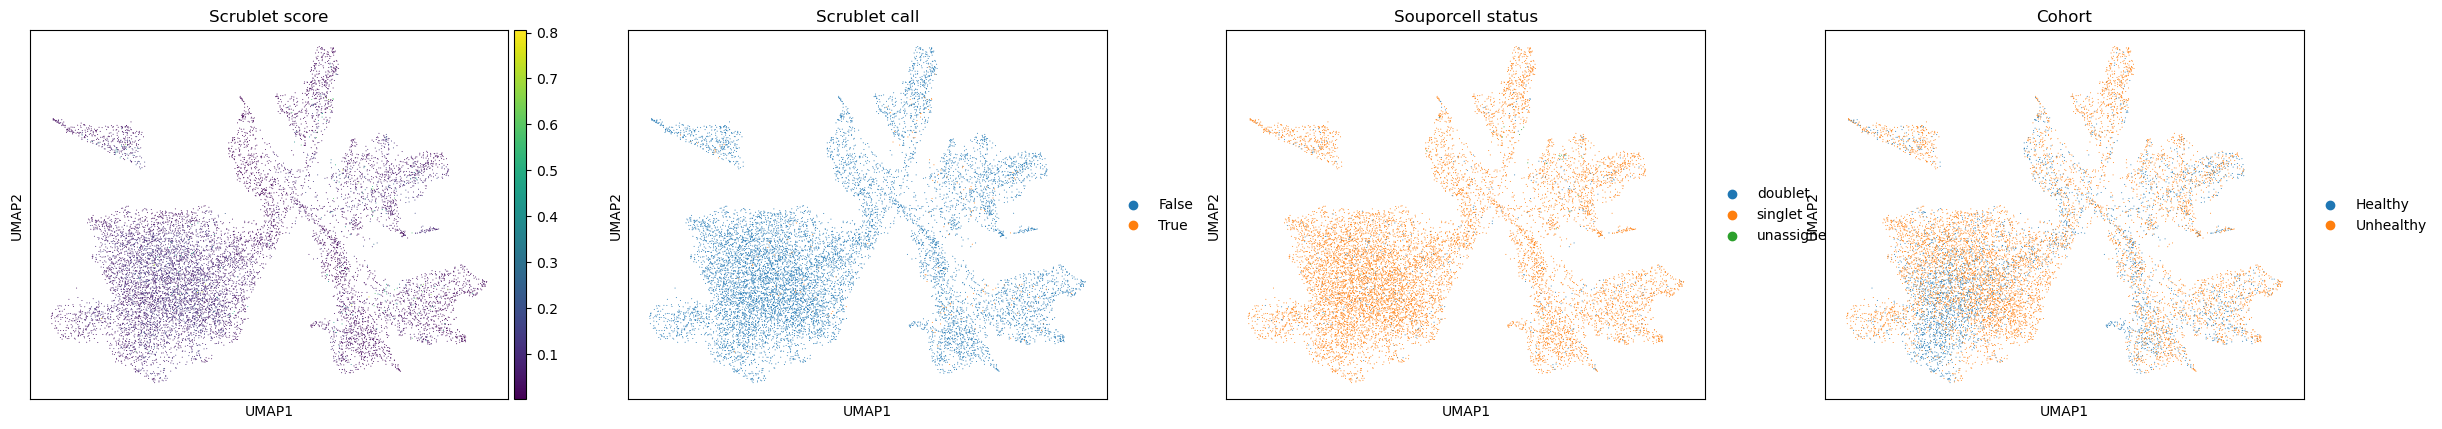

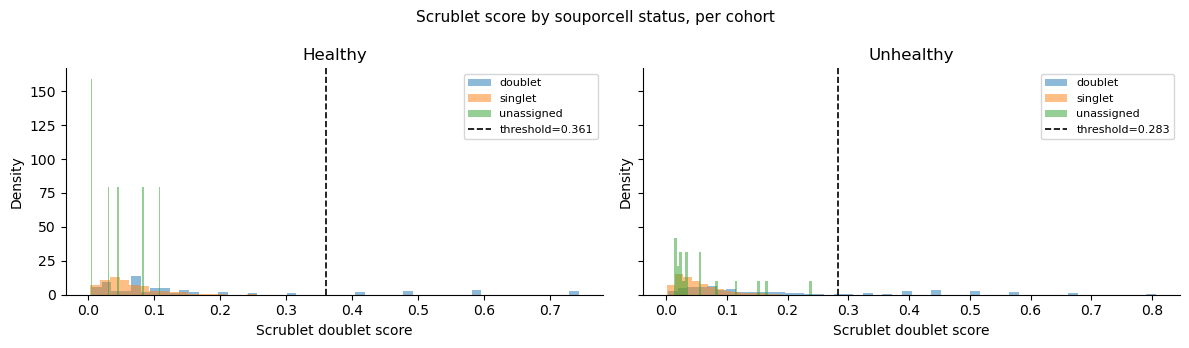

In [18]:
# UMAP
sc.pl.umap(adata_nan,
           color=["scrublet_score", "scrublet_call", "status", "cohort"],
           ncols=4, size=2,
           title=["Scrublet score", "Scrublet call", "Souporcell status", "Cohort"])

# Score distributions by souporcell status, per cohort
fig, axes2 = plt.subplots(1, len(cohorts), figsize=(6 * len(cohorts), 3.5), sharey=True)
for i, cohort in enumerate(cohorts):
    ax   = axes2[i]
    mask = adata_nan.obs["cohort"] == cohort
    sub  = adata_nan.obs.loc[mask]
    for label, grp in sub.groupby("status"):
        ax.hist(grp["scrublet_score"], bins=50, alpha=0.5, label=label, density=True)
    thr = scrublet_thresholds[cohort]
    ax.axvline(thr, color="black", lw=1.2, ls="--", label=f"threshold={thr:.3f}")
    ax.set_xlabel("Scrublet doublet score")
    ax.set_ylabel("Density")
    ax.set_title(cohort)
    ax.legend(fontsize=8)
    sns.despine(ax=ax)
fig.suptitle("Scrublet score by souporcell status, per cohort", fontsize=11)
plt.tight_layout()
plt.show()


In [19]:
leiden_clusters = {}

for leiden_cluster, counts in vc.groupby(level=0):
    
    percents = counts / counts.sum()
    
    leiden_celltype = "/".join(percents[percents > 0.3].index.get_level_values("cell_type").fillna("NaN").astype(str).tolist())
    leiden_cells = adata_nan.obs.loc[(adata_nan.obs["leiden"] == leiden_cluster),:]
    doublets_souporcell = leiden_cells.loc[leiden_cells["status"] == "doublet", :]
    doublets_scrublet = leiden_cells.loc[leiden_cells["scrublet_call"], :]
    nans = leiden_cells.loc[leiden_cells["cell_type"].isna(), :]
    nans_n_scrublet = leiden_cells.loc[leiden_cells["scrublet_call"] & leiden_cells["cell_type"].isna(), :]

    percent_of_doublets_souporcell = doublets_souporcell.shape[0] / leiden_cells.shape[0]
    percent_of_doublets_scrublet = doublets_scrublet.shape[0] / leiden_cells.shape[0]
    percent_nans = nans.shape[0] / leiden_cells.shape[0]

    percent_nans_n_scrublet = nans_n_scrublet.shape[0] / leiden_cells.shape[0]
    
    # nan_n_doublets
    
    leiden_clusters[leiden_cluster] = {
        "leiden": leiden_cluster,
        "cell_type": leiden_celltype,
        "percent_doublets_souporcell": percent_of_doublets_souporcell,
        "percent_doublets_scrublet": percent_of_doublets_scrublet,
        "percent_nans": percent_nans,
        "percent_nans&scrublet": percent_nans_n_scrublet
    }


In [20]:
leiden_clusters_df = pd.DataFrame.from_dict(leiden_clusters, orient="index")
leiden_clusters_df.sort_values("percent_doublets_souporcell", ascending=False)

,leiden,cell_type,percent_doublets_souporcell,percent_doublets_scrublet,percent_nans,percent_nans&scrublet
20,20,T cells,0.277778,0.000000,0.277778,0.000000
24,24,B cells,0.098039,0.039216,0.098039,0.019608
14,14,NK cells/T cells,0.084592,0.051360,0.099698,0.042296
21,21,Myeloid cells,0.078431,0.043137,0.258824,0.027451
30,30,Myeloid cells,0.061905,0.033333,0.109524,0.023810
31,31,Myeloid cells,0.060976,0.000000,0.060976,0.000000
34,34,FAPs,0.060606,0.040404,0.080808,0.040404
28,28,Myofibroblasts,0.060209,0.026178,0.065445,0.015707
0,0,Myeloid cells,0.055300,0.027650,0.094470,0.020737
16,16,FAPs,0.050971,0.000000,0.055825,0.000000


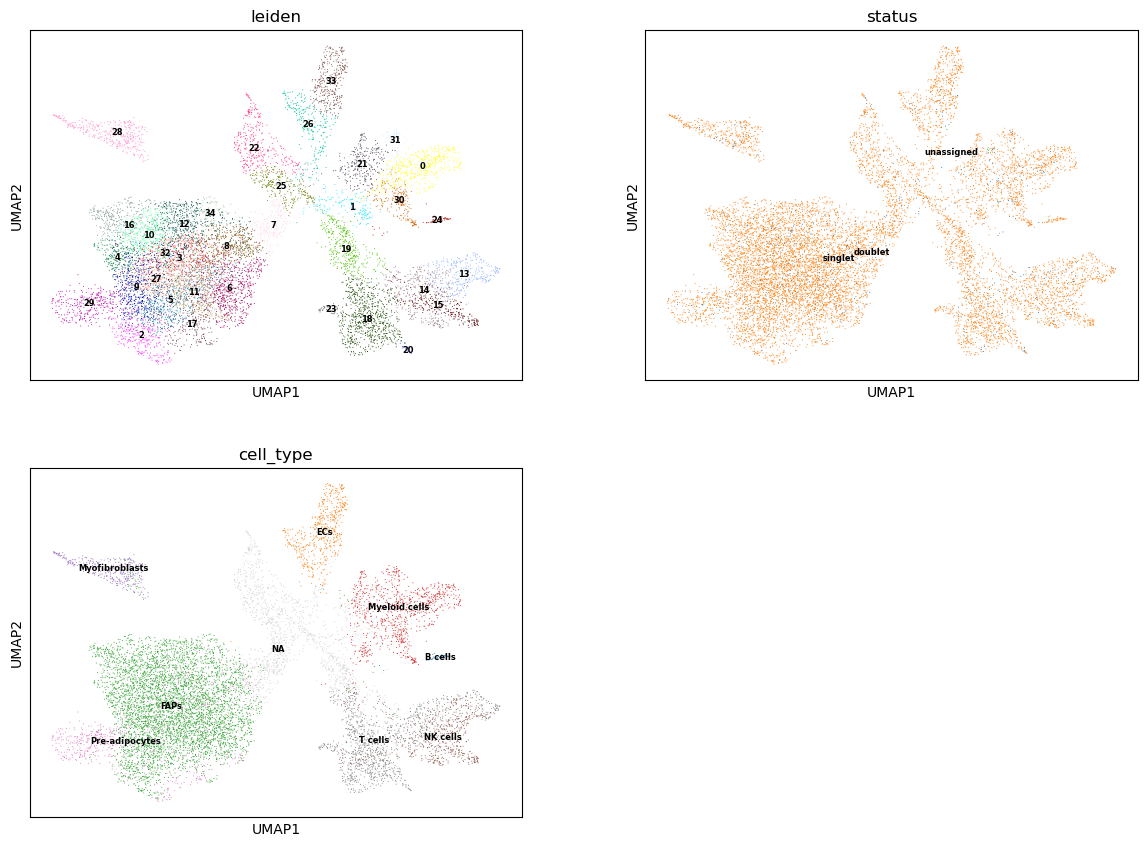

In [21]:
sc.pl.umap(adata_nan, color=["leiden", "status", "cell_type"], legend_loc="on data", legend_fontsize=6, ncols=2, size=2)

In [22]:
with pd.option_context('display.max_rows', 300):
    print(adata_nan.obs.value_counts(["leiden", "status", "scrublet_call"]).sort_index())

leiden  status      scrublet_call
0       doublet     False             15
                    True               9
        singlet     False            404
                    True               3
        unassigned  False              3
                    True               0
1       doublet     False              5
                    True               1
        singlet     False            149
                    True               2
        unassigned  False              1
                    True               0
2       doublet     False              5
                    True               1
        singlet     False            319
                    True               1
        unassigned  False              0
                    True               0
3       doublet     False              8
                    True               5
        singlet     False            425
                    True               1
        unassigned  False              2
                    Tru

In [23]:
cols = ["scrublet_score", "scrublet_call"]
adata_an.obs[cols] = adata_nan.obs.loc[adata_an.obs_names, cols].values

In [24]:
adata_an.obs["scrublet_call"] = adata_an.obs["scrublet_call"].astype(bool)
adata_an.obs["scrublet_score"] = adata_an.obs["scrublet_score"].astype(float)

In [25]:
import anndata as ad
ad.settings.allow_write_nullable_strings = True
adata_an.write_h5ad(os.path.join(INPUT_DIR, "anndatas", 'sq_reannotated_finely.h5ad'))